# **Basics of Probability**

**1. Write a Python program to simulate the following scenarios:**

   

       a. Tossing a coin 10,000 times and calculating the experimental probability of heads and tails.

In [1]:
import random

In [13]:
heads=0
tails=0

for i in range(10000):

  toss = random.choice(['H','T'])

  if toss == 'H':
    heads+=1
  else:
    tails+=1

print("Probability of Heads:", heads/10000)
print("Probability of Tails:", tails/10000)

Probability of Heads: 0.4968
Probability of Tails: 0.5032


the code uses the count logic wheere the coin flips 10000 times and in that using random.choice H or T gets selected.

if H then the count gets updated

### Observation:

The experimental probabilities of heads and tails were close to 0.5, which matches the theoretical probability of a fair coin. This demonstrates the Law of Large Numbers, where the results of a simulation become more accurate as the number of trials increases.

**b. Rolling two dice and computing the probability of getting a sum of 7**

In [20]:
sum7_count = 0

n= 150

for i in range(n):

  die1 = random.randint(1,6)
  die2 = random.randint(1,6)

  if die1 + die2 == 7:
    sum7_count += 1

pro = sum7_count / n

print("Number of times getting a sum of 7 :", sum7_count)
print("Probability of getting a sum of 7 : ", pro)

Number of times getting a sum of 7 : 26
Probability of getting a sum of 7 :  0.17333333333333334


### Observation

The experimental probability is close to the theoretical probability of 0.1667 (1/6).

Minor differences occur due to randomness in the simulation. Increasing the number of trials generally makes the experimental probability closer to the theoretical value.

**2. Write a function to estimate the probability of getting at least one "6" in 10 rolls of a fair die.**

In [28]:
trials = 100
count = 0

for i in  range(trials):

  found_six = False

  # Roll the die 10 times
  for i in range(10):

    roll = random.randint(1,6)

    if roll == 6:
        found_six = True

  if found_six:
    count += 1

print("Numbers of time getting 6 in 10 roles in",f"{trials} trials :" ,count)
print("Probability of getting atleast one 6 in 10 rolls : ", count/trials)


Numbers of time getting 6 in 10 roles in 100 trials : 85
Probability of getting atleast one 6 in 10 rolls :  0.85


We created 2 loops , using nested loop concept , 1st 1 loop runs to fullfills required trails then the other loop performs 10 rolls for each trial.

### Observation

The estimated probability is usually around 0.83. This means there is a high chance of getting at least one 6 when rolling a fair die 10 times. The result is close to the theoretical probability and demonstrates how simulation can be used to estimate probabilities.

# **Conditional Probability and Bayes' Theorem**


**3. A bag contains 5 red, 7 green, and 8 blue balls. A ball is drawn randomly, its color noted, and it is put back into the bag. If this process is repeated 1000 times, write a Python program to estimate:**


    a. The probability of drawing a red ball given that the previous ball was blue.
    


In [31]:
draws = []

for i in range(10000):

    color = random.choices(
        ['red', 'green', 'blue'],
        weights=[5, 7, 8],
        k=1
      )[0]

    draws.append(color)

previous_blue = 0
blue_then_red = 0


for i in  range(1, len(draws)):

  if draws[i-1] == "blue":
    previous_blue += 1

    if draws[i] == "red":
      blue_then_red += 1

p_red_given_blue = blue_then_red / previous_blue
print("Probability of drawing a red ball  after a blue : ", p_red_given_blue) #P(R∣B)


Probability of drawing a red ball  after a blue :  0.2389248382279741


* Created an empty list to store the colors from each draw.
* Simulated 10,000 draws using `random.choices()` with weights `[5, 7, 8]`.
* Stored each selected color in the list.
* Used two counters to track how many times a blue ball was followed by another draw and how many times it was followed by a red ball.
* Traversed the list and checked consecutive draws.
* Calculated the conditional probability by dividing the Blue→Red count by the total number of times the previous ball was blue.

**b. Verify Bayes' theorem with the simulation results.**

Bayes' Theorem :

`P(A∣B)` = `P(B)` **/**
       `P(B∣A) × P(A)`

HERE :

`P(R∣B)` = `P(B)` **/**
       `P(B∣R) × P(R)`

where:

P(R∣B) = Probability of Red given previous Blue

P(B∣R) = Probability of Blue given previous Red

P(R) = Probability that a draw is Red

P(B) = Probability that a draw is Blue

In [32]:
previous_red = 0
red_then_blue = 0

p_red = draws.count("red") / len(draws) #P(R)
p_blue = draws.count("blue") / len(draws) #P(B)

for i in range(1, len(draws)):

    if draws[i-1] == "red":
        previous_red += 1

        if draws[i] == "blue":
            red_then_blue += 1

p_blue_given_red = red_then_blue / previous_red #P(B∣R)

#P(R∣B)
bayes_result = (p_blue_given_red * p_red) / p_blue

print(f"P(Red | Blue) from simulation = {p_red_given_blue}")
print(f"P(Red | Blue) using Bayes theorem = {bayes_result}")

P(Red | Blue) from simulation = 0.2389248382279741
P(Red | Blue) using Bayes theorem = 0.25155511321224183


The value obtained using Bayes' theorem was very close to the value calculated directly from the simulation. The small difference is due to randomness in the simulated data. Increasing the number of draws would reduce this difference and produce a closer match.

# **Random Variables and Discrete Probability**

**4. Generate a sample of size 1000 from a discrete random variable with the following distribution:**
 - P(X=1) = 0.25
 - P(X=2) = 0.35
 - P(X=3) = 0.4

**Compute the empirical mean, variance, and standard deviation of the sample.**

In [33]:
import numpy as np

sample = np.random.choice(
    [1, 2, 3],
    size=1000,
    p=[0.25, 0.35, 0.40]
) #generating the sample

mean = np.mean(sample)
variance = np.var(sample)
std_dev = np.std(sample)

print("Sample mean:", mean)
print("Sample variance:", variance)
print("Sample standard deviation:", std_dev)

Sample mean: 2.194
Sample variance: 0.612364
Sample standard deviation: 0.7825369000884239


- sample is generated using NumPy library , sample follows the given probability distribution.
- The mean represents the average value of the random variable.
- Variance and standard deviation indicate how much the values vary from the mean.
- Since the sample is randomly generated, the results may vary slightly each time the program is executed.

# **Continuous Random Variables**


**5. Simulate 2000 random samples from an exponential distribution with a mean of 5.**

**Visualize the distribution using:**

    a. A histogram.

    b. A probability density function (PDF) overlay.


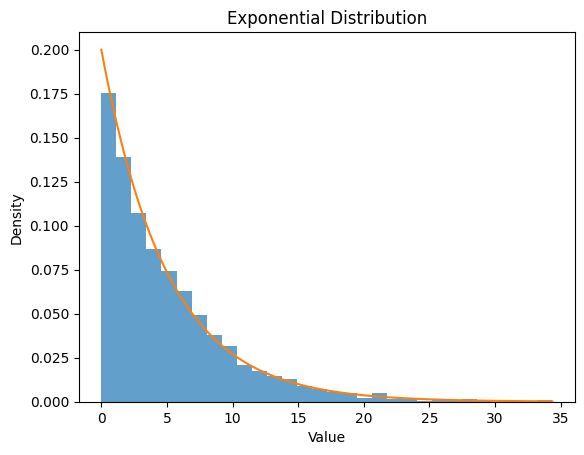

In [34]:
#Syntax : np.random.exponential(scale, size)
#Scale = 5

import matplotlib.pyplot as plt
import numpy as np

samples = np.random.exponential(scale=5,size=2000) #generated sample

# Histogram
plt.hist(samples, bins=30, density=True, alpha=0.7)

# PDF
x = np.linspace(0, max(samples), 1000)
pdf = (1/5) * np.exp(-x/5)

plt.plot(x, pdf)

plt.title("Exponential Distribution")
plt.xlabel("Value")
plt.ylabel("Density")

plt.show()

- Generated 2000 random samples from an exponential distribution with mean 5 using `np.random.exponential()`.
- Created a histogram to visualize the distribution of the generated samples.
- Generated x-values and calculated the theoretical PDF of the exponential distribution.
- Plotted the PDF curve on top of the histogram for comparison.

# **Central Limit Theorem**

**6. Simulate the Central Limit Theorem by following these steps**

    a. Generate 10,000 random numbers from a uniform distribution.

    b. Draw 1000 samples of size n = 30.
    
    c. Calculate and visualize the distribution of sample means.


CLT says:

Even if the original data is not normally distributed, the distribution of sample means tends to become approximately normal when the sample size is large enough.

In [35]:
import numpy as np
import matplotlib.pyplot as plt

population = np.random.uniform(0, 1, 10000) #generatinf numbers from a uniform dist.


# Generate sample means
sample_means = []

for i in range(1000):

    sample = np.random.choice(population,size=30) #generate samples from population(10000 numbers), total 30 numbers in each sample

    sample_means.append(np.mean(sample))


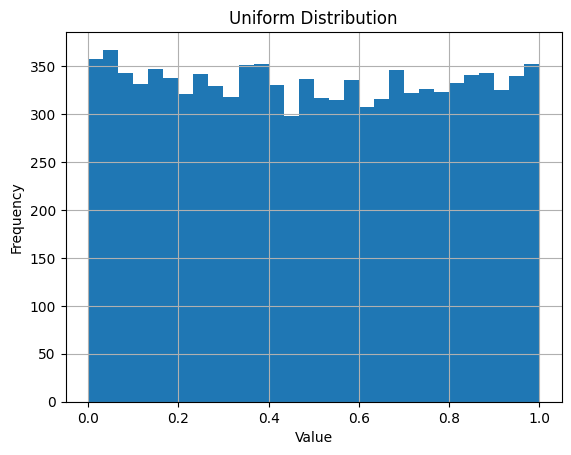

In [37]:
#PLOTING ( VISUALIZING )

# Uniform distribution
plt.hist(population, bins=30)

plt.title("Uniform Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

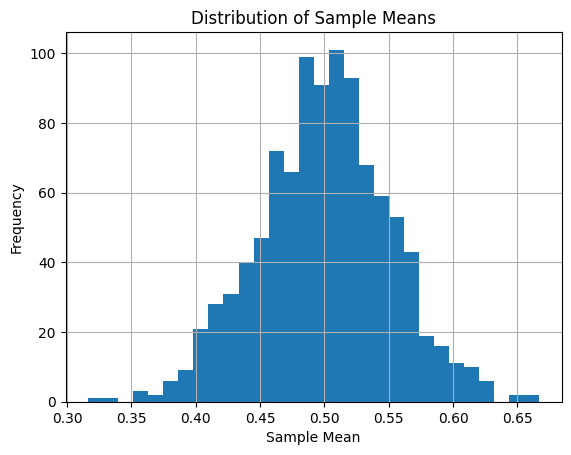

In [38]:
# Distribution of sample means
plt.hist(sample_means, bins=30)

plt.title("Distribution of Sample Means")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

### Logic

- Generated 10,000 random values from a uniform distribution.
- Created an empty list to store sample means.
- Repeated the sampling process 1000 times.
- Selected a random sample of 30 values and calculated its mean.
- Stored each mean in the list.
- Plotted the original uniform distribution and the distribution of sample means for comparison.

### Observation

The original data was generated from a uniform distribution, which is approximately flat. However, the histogram of the sample means forms a bell-shaped curve centered around 0.5. Most sample means are concentrated near the center, while extreme values occur less frequently. This demonstrates the Central Limit Theorem, which states that the distribution of sample means tends to become approximately normal even when the original population is not normally distributed.